# Camera Calibration and Lens Undistortion  

### Import Required Libraries

In [37]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

### Load Images

In [47]:
images = glob.glob("Documents/AIML-Assessment/Module-2/Task-10/calibration_images/*.jpeg")

### Locate & Refine Internal Corners

In [48]:
objp = np.zeros((8*6, 3), np.float32)
objp[:, :2] = np.mgrid[0:8, 0:6].T.reshape(-1, 2)
criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER,30,0.001)
objpoints = []
imgpoints = []

In [56]:
for image in images:
    img = cv2.imread(image)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(img_gray,(8,6))
    if ret:
        corners = cv2.cornerSubPix(img_gray,corners,(11,11),(-1,-1),criteria)
        objpoints.append(objp)
        imgpoints.append(corners)

### Compute Camera Matrix & Distortion Coefficient

In [58]:
ret, camera_matrix, dist_coeff, rvecs, tvecs = cv2.calibrateCamera(objpoints,imgpoints,img_gray.shape[::-1],None,None)
print("Camera Matrix: \n",camera_matrix)
print("Distortion Coefficient: ",dist_coeff)

Camera Matrix: 
 [[1.21802122e+03 0.00000000e+00 7.22025150e+02]
 [0.00000000e+00 1.21015335e+03 7.20213876e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficient:  [[ 0.00094881 -0.14559615 -0.00108164  0.00334848  0.29368484]]


### Focal Lengths & Pricipal Point

In [51]:
fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

In [52]:
print("INTRINSIC PARAMETERS")
print(f"fx = {fx:.3f}")
print(f"fy = {fy:.3f}")
print(f"cx = {cx:.3f}")
print(f"cy = {cy:.3f}")

INTRINSIC PARAMETERS
fx = 1218.021
fy = 1210.153
cx = 722.025
cy = 720.214


### Reprojection Error

In [59]:
total_error = 0
for i in range(len(objpoints)):
    projected_points, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], camera_matrix, dist_coeff)
    error = cv2.norm(imgpoints[i], projected_points, cv2.NORM_L2) / len(projected_points)
    total_error += error
mean_error = total_error / len(objpoints)
print(f"Mean Reprojection Error = {mean_error:.4f} pixels")

Mean Reprojection Error = 0.3392 pixels


### Undistort

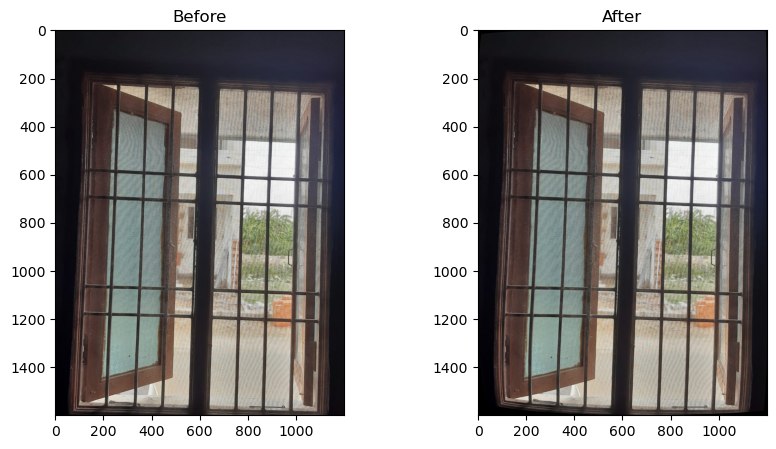

In [55]:
img = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/scene.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
undistorted = cv2.undistort(img_rgb,camera_matrix,dist_coeff)
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].set_title("Before")
axes[0].imshow(img_rgb)
axes[1].set_title("After")
axes[1].imshow(undistorted)

### Note

Visual comparison between the original and undistorted images shows geometric correction near the image boundaries. Straight structural elements such as the window frame and vertical bars appear slightly adjusted after undistortion. The correction is most noticeable near the edges of the image, where lens distortion effects are typically strongest.